# Load and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cont_cols = [
    'visitor_hist_starrating',
    'visitor_hist_adr_usd',
    'prop_review_score',
    'prop_location_score1',
    'prop_location_score2',
    'prop_log_historical_price',
    'price_usd',
    'srch_query_affinity_score',
    'orig_destination_distance',
    'gross_bookings_usd',
    'comp1_rate_percent_diff',
    'comp2_rate_percent_diff',
    'comp3_rate_percent_diff',
    'comp4_rate_percent_diff',
    'comp5_rate_percent_diff',
    'comp6_rate_percent_diff',
    'comp7_rate_percent_diff',
    'comp8_rate_percent_diff'
]

bool_cols = [
    'prop_brand_bool',
    'promotion_flag',
    'srch_saturday_night_bool',
    'random_bool',
    'click_bool',
    'booking_bool'
]

id_cols = [
    'srch_id',
    'site_id',
    'visitor_location_country_id',
    'prop_country_id',
    'prop_id',
    'srch_destination_id'
]

cat_cols = [
    'comp1_rate', 'comp1_inv',
    'comp2_rate', 'comp2_inv',
    'comp3_rate', 'comp3_inv',
    'comp4_rate', 'comp4_inv',
    'comp5_rate', 'comp5_inv',
    'comp6_rate', 'comp6_inv',
    'comp7_rate', 'comp7_inv',
    'comp8_rate', 'comp8_inv'
]

int_cols = [
    'prop_starrating',
    'position',
    'srch_length_of_stay',
    'srch_booking_window',
    'srch_adults_count',
    'srch_children_count',
    'srch_room_count'
]

In [3]:
dtype_dict = {}

# float columns
for col in cont_cols:
    dtype_dict[col] = 'float32'

# bool columns
for col in bool_cols:
    dtype_dict[col] = 'bool'

# id columns
for col in id_cols:
    dtype_dict[col] = 'int32'

# categorical columns
for col in cat_cols:
    dtype_dict[col] = 'category'

# small integer columns
for col in int_cols:
    dtype_dict[col] = 'int8'

In [4]:
df = pd.read_csv(
    "../data/training_set_VU_DM.csv",
    dtype=dtype_dict,
    low_memory=False
)

In [5]:
print(df.shape)
df.head()

(4958347, 54)


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1,0,5.0,False,NaN,False
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False


# Part 4 - Data Preparation

## 4.1 Data Cleaning

### 4.1.1 Data Types

In [6]:
# Adding Date
df["date_time"] = pd.to_datetime(df["date_time"])
date_col = df["date_time"].dt.floor("D")
df.insert(2, "date", date_col)
time_cols = ['date_time', 'date']
df.head()

,srch_id,date_time,date,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,893,3,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False
1,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,10404,4,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False
2,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,21315,3,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False
3,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,27348,2,...,NaN,NaN,NaN,NaN,-1,0,5.0,False,NaN,False
4,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,29604,4,...,NaN,NaN,NaN,NaN,0,0,NaN,False,NaN,False


In [7]:
# Checking Column Numbers
print(df.shape[1])
col_len = len(cont_cols) + len(bool_cols) + len(id_cols) + len(int_cols) + len(time_cols) + len(cat_cols)
print(col_len)

55
55


In [8]:
df.dtypes

srch_id                                 int32
date_time                      datetime64[ns]
date                           datetime64[ns]
site_id                                 int32
visitor_location_country_id             int32
visitor_hist_starrating               float32
visitor_hist_adr_usd                  float32
prop_country_id                         int32
prop_id                                 int32
prop_starrating                          int8
prop_review_score                     float32
prop_brand_bool                          bool
prop_location_score1                  float32
prop_location_score2                  float32
prop_log_historical_price             float32
position                                 int8
price_usd                             float32
promotion_flag                           bool
srch_destination_id                     int32
srch_length_of_stay                      int8
srch_booking_window                      int8
srch_adults_count                 

### 4.1.2 Target Engineering

In [9]:
df["target"] = 5 * df["booking_bool"] + 1 * df["click_bool"]
df["target"] = df["target"].astype("int8")

In [10]:
df.dtypes[-3:]

gross_bookings_usd    float32
booking_bool             bool
target                   int8
dtype: object

### 4.1.4 Capping wrong values and outliers

### Search Booking Window

In [11]:
# Create Negative Flag Feature for booking_window
df["booking_window_was_negative"] = (df["srch_booking_window"] < 0).astype("bool")

# Clip Values
df["srch_booking_window"] = df["srch_booking_window"].clip(lower = 0)

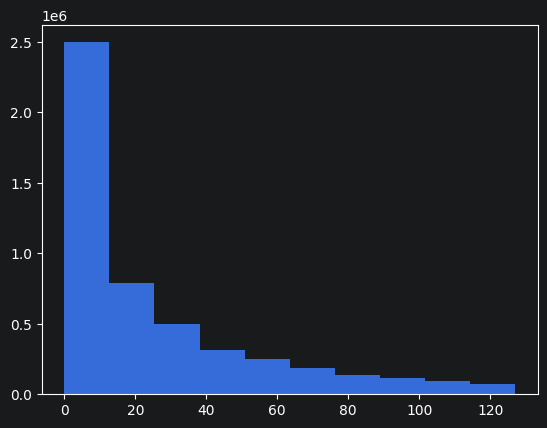

In [12]:
plt.figure()
plt.hist(df["srch_booking_window"])
plt.show()

### Competition Rate Diff

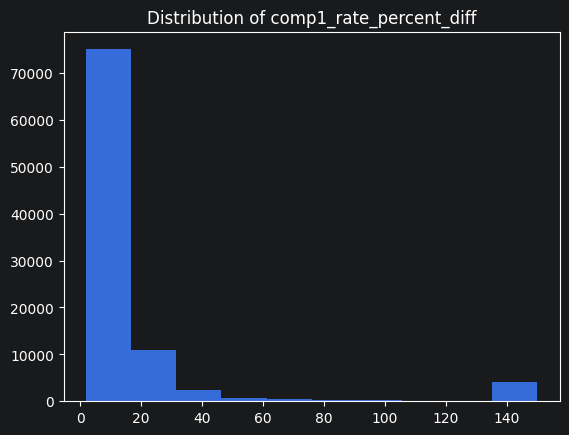

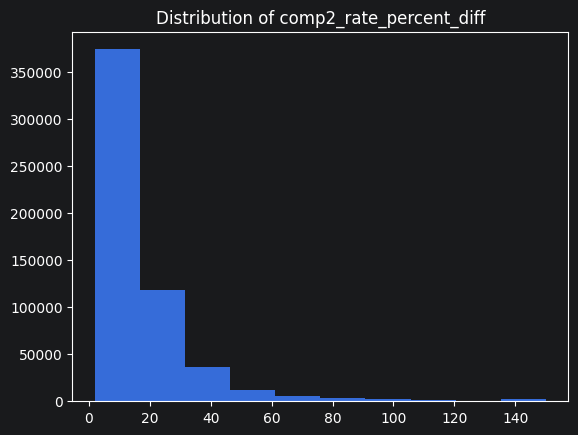

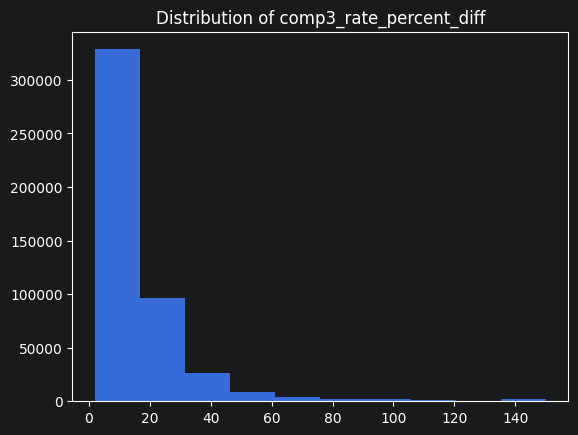

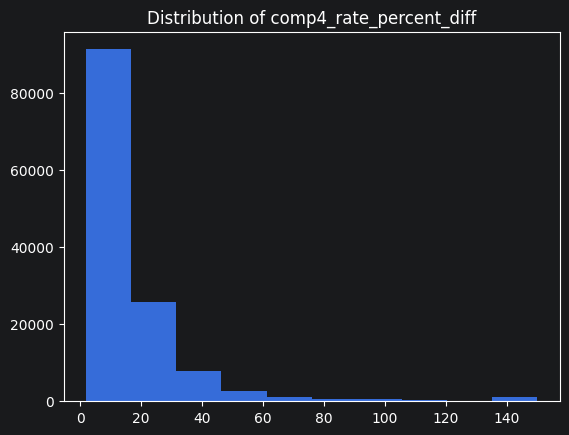

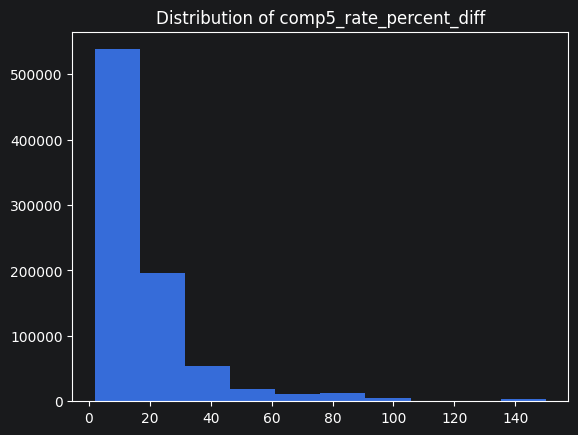

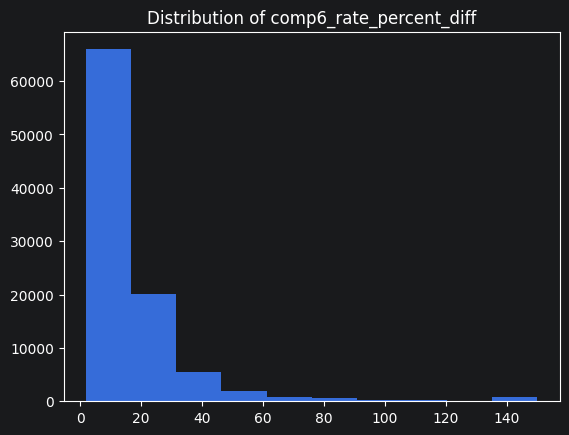

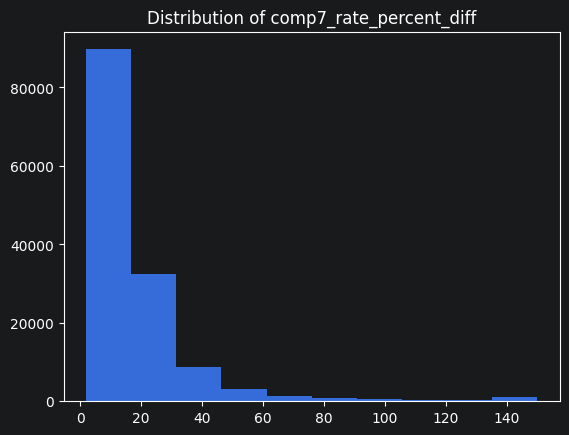

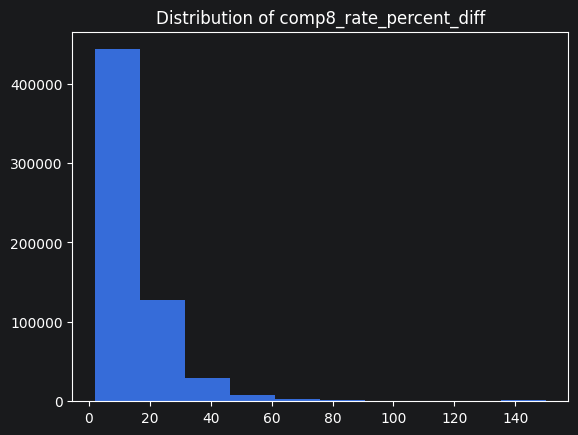

In [13]:
upper_limit = 150
for i in range(1, 9):
    df[f"comp{i}_rate_percent_diff"] = df[f"comp{i}_rate_percent_diff"].clip(upper = upper_limit)
    plt.figure()
    plt.hist(df[f"comp{i}_rate_percent_diff"])
    plt.title(f"Distribution of comp{i}_rate_percent_diff")
    plt.show()

### Creating Boolean Features where needed before Train-Val Split

In [14]:
# Prop Starrating - No Stars
df["no_starrating"] = (df["prop_starrating"] == 0)

# Prop Log Historical Price
df["prop_no_sold"] = (df["prop_log_historical_price"] == 0)

# Prop Review Score
df["no_review"] = (df["prop_review_score"] == 0)

# No Distance
df["missing_distance"] = (df["orig_destination_distance"].isna())

# Search Query Affinity
df["no_affinity"] = (df["srch_query_affinity_score"].isna())

# Visitor History
df["no_vis_hist"] = (df["visitor_hist_starrating"].isna())

# Competitor Difference
for i in range(1, 9):
    df[f"has_comp{i}_diff"] = (df[f"comp{i}_rate_percent_diff"].notna())


### Train-Validation Split

In [15]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    test_size=0.2,
    n_splits=1,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(df, groups=df['srch_id'])
)

train_df = df.iloc[train_idx].copy()
val_df = df.iloc[val_idx].copy()

### Price USD

In [16]:
# Create quantile using only Training Set
price_995 = train_df["price_usd"].quantile(q = 0.995)

# Cap for both Train and Validation Set
train_df["price_usd"] = train_df["price_usd"].clip(upper = price_995)
val_df["price_usd"] = val_df["price_usd"].clip(upper = price_995)

### 4.1.5 Handling Null and 0 Values

### Property Starrating - 0 values

In [17]:
# Replace unknown 0 values with NaN
train_df["prop_starrating"] = (
    train_df["prop_starrating"]
    .replace(0, np.nan)
)

val_df["prop_starrating"] = (
    val_df["prop_starrating"]
    .replace(0, np.nan)
)

# Compute mode ONLY from training set
mode_starrating = (
    train_df["prop_starrating"]
    .mode()[0]
)

# Impute using training mode
train_df["prop_starrating"] = (
    train_df["prop_starrating"]
    .fillna(mode_starrating)
    .astype("int8")
)

val_df["prop_starrating"] = (
    val_df["prop_starrating"]
    .fillna(mode_starrating)
    .astype("int8")
)

### Prop Log Historical Price - 0 Values

In [18]:
# Replace 0 values with NaN
train_df.loc[:, "prop_log_historical_price"] = (
    train_df["prop_log_historical_price"]
    .replace(0, np.nan)
)

val_df.loc[:, "prop_log_historical_price"] = (
    val_df["prop_log_historical_price"]
    .replace(0, np.nan)
)

# Compute median ONLY from training set
median_hist_price = (
    train_df["prop_log_historical_price"]
    .median()
)

# Impute using training median
train_df.loc[:, "prop_log_historical_price"] = (
    train_df["prop_log_historical_price"]
    .fillna(median_hist_price)
    .astype("float32")
)

val_df.loc[:, "prop_log_historical_price"] = (
    val_df["prop_log_historical_price"]
    .fillna(median_hist_price)
    .astype("float32")
)

### Prop Review Score

In [19]:
# --------------------------------------------------
# PROP REVIEW SCORE IMPUTATION
# --------------------------------------------------

# Convert semantic missing values to NaN
train_df.loc[:, "prop_review_score"] = (
    train_df["prop_review_score"]
    .replace(0, np.nan)
)

val_df.loc[:, "prop_review_score"] = (
    val_df["prop_review_score"]
    .replace(0, np.nan)
)

# --------------------------------------------------
# Compute hotel-specific medians USING TRAIN ONLY
# --------------------------------------------------

hotel_review_medians = (
    train_df
    .groupby("prop_id", observed = True)["prop_review_score"]
    .median()
)

# --------------------------------------------------
# Map hotel medians
# --------------------------------------------------

train_hotel_medians = (
    train_df["prop_id"]
    .map(hotel_review_medians)
)

val_hotel_medians = (
    val_df["prop_id"]
    .map(hotel_review_medians)
)

# --------------------------------------------------
# Fill NaNs with hotel median
# --------------------------------------------------

train_df.loc[:, "prop_review_score"] = (
    train_df["prop_review_score"]
    .fillna(train_hotel_medians)
)

val_df.loc[:, "prop_review_score"] = (
    val_df["prop_review_score"]
    .fillna(val_hotel_medians)
)

# --------------------------------------------------
# Compute GLOBAL median USING TRAIN ONLY
# --------------------------------------------------

global_review_median = (
    train_df["prop_review_score"]
    .median()
)

# --------------------------------------------------
# Final fallback to global median
# --------------------------------------------------

train_df.loc[:, "prop_review_score"] = (
    train_df["prop_review_score"]
    .fillna(global_review_median)
    .astype("float32")
)

val_df.loc[:, "prop_review_score"] = (
    val_df["prop_review_score"]
    .fillna(global_review_median)
    .astype("float32")
)

### Prop Location Score

In [20]:
# --------------------------------------------------
# PROP LOCATION SCORE 2 IMPUTATION
# --------------------------------------------------

# Compute hotel-specific medians USING TRAIN ONLY
hotel_location_medians = (
    train_df
    .groupby("prop_id", observed = True)["prop_location_score2"]
    .median()
)

# Map hotel medians
train_hotel_location_medians = (
    train_df["prop_id"]
    .map(hotel_location_medians)
)

val_hotel_location_medians = (
    val_df["prop_id"]
    .map(hotel_location_medians)
)

# Fill missing values with hotel median
train_df.loc[:, "prop_location_score2"] = (
    train_df["prop_location_score2"]
    .fillna(train_hotel_location_medians)
)

val_df.loc[:, "prop_location_score2"] = (
    val_df["prop_location_score2"]
    .fillna(val_hotel_location_medians)
)

# Compute GLOBAL median USING TRAIN ONLY
global_location_median = (
    train_df["prop_location_score2"]
    .median()
)

# Final fallback to global median
train_df.loc[:, "prop_location_score2"] = (
    train_df["prop_location_score2"]
    .fillna(global_location_median)
    .astype("float32")
)

val_df.loc[:, "prop_location_score2"] = (
    val_df["prop_location_score2"]
    .fillna(global_location_median)
    .astype("float32")
)

### Orig Destination Distance

In [21]:
# Compute median USING TRAIN ONLY
distance_median = (
    train_df["orig_destination_distance"]
    .median()
)

# Impute
train_df.loc[:, "orig_destination_distance"] = (
    train_df["orig_destination_distance"]
    .fillna(distance_median)
    .astype("float32")
)

val_df.loc[:, "orig_destination_distance"] = (
    val_df["orig_destination_distance"]
    .fillna(distance_median)
    .astype("float32")
)

### Search Query Affinity

In [22]:
# --------------------------------------------------
# SRCH QUERY AFFINITY SCORE IMPUTATION
# --------------------------------------------------

# Compute median USING TRAIN ONLY
affinity_median = (
    train_df["srch_query_affinity_score"]
    .median()
)

# Impute missing values
train_df.loc[:, "srch_query_affinity_score"] = (
    train_df["srch_query_affinity_score"]
    .fillna(affinity_median)
    .astype("float32")
)

val_df.loc[:, "srch_query_affinity_score"] = (
    val_df["srch_query_affinity_score"]
    .fillna(affinity_median)
    .astype("float32")
)

### Visitor History

In [23]:
# --------------------------------------------------
# VISITOR HISTORY STARRATING IMPUTATION
# --------------------------------------------------

# Compute median USING TRAIN ONLY
visitor_star_median = (
    train_df["visitor_hist_starrating"]
    .median()
)

# Impute missing values
train_df.loc[:, "visitor_hist_starrating"] = (
    train_df["visitor_hist_starrating"]
    .fillna(visitor_star_median)
    .astype("float32")
)

val_df.loc[:, "visitor_hist_starrating"] = (
    val_df["visitor_hist_starrating"]
    .fillna(visitor_star_median)
    .astype("float32")
)


# --------------------------------------------------
# VISITOR HISTORY ADR USD IMPUTATION
# --------------------------------------------------

# Compute median USING TRAIN ONLY
visitor_adr_median = (
    train_df["visitor_hist_adr_usd"]
    .median()
)

# Impute missing values
train_df.loc[:, "visitor_hist_adr_usd"] = (
    train_df["visitor_hist_adr_usd"]
    .fillna(visitor_adr_median)
    .astype("float32")
)

val_df.loc[:, "visitor_hist_adr_usd"] = (
    val_df["visitor_hist_adr_usd"]
    .fillna(visitor_adr_median)
    .astype("float32")
)

### Competition Rate and Inv

In [24]:
for i in range(1, 9):

    train_df[f"comp{i}_rate"] = (
        train_df[f"comp{i}_rate"]
        .astype("float32")
        .fillna(99)
        .astype("category")
    )

    val_df[f"comp{i}_rate"] = (
        val_df[f"comp{i}_rate"]
        .astype("float32")
        .fillna(99)
        .astype("category")
    )

    train_df[f"comp{i}_inv"] = (
        train_df[f"comp{i}_inv"]
        .astype("float32")
        .fillna(99)
        .astype("category")
    )

    val_df[f"comp{i}_inv"] = (
        val_df[f"comp{i}_inv"]
        .astype("float32")
        .fillna(99)
        .astype("category")
    )

### Competition Rate Diff

In [25]:
# --------------------------------------------------
# COMPETITOR RATE PERCENT DIFFERENCE IMPUTATION
# --------------------------------------------------

for i in range(1, 9):

    col = f"comp{i}_rate_percent_diff"

    # Compute median USING TRAIN ONLY
    comp_median = (
        train_df[col]
        .median()
    )

    # Impute missing values
    train_df.loc[:, col] = (
        train_df[col]
        .fillna(comp_median)
        .astype("float32")
    )

    val_df.loc[:, col] = (
        val_df[col]
        .fillna(comp_median)
        .astype("float32")
    )

### Checking Imputation Result

In [26]:
train_df.isna().sum().sort_values(ascending = False)[:20]

gross_bookings_usd             3855821
date_time                            0
srch_id                              0
site_id                              0
visitor_location_country_id          0
visitor_hist_starrating              0
date                                 0
visitor_hist_adr_usd                 0
prop_country_id                      0
prop_starrating                      0
prop_id                              0
prop_brand_bool                      0
prop_location_score1                 0
prop_location_score2                 0
prop_review_score                    0
position                             0
price_usd                            0
promotion_flag                       0
srch_destination_id                  0
srch_length_of_stay                  0
dtype: int64

In [27]:
val_df.isna().sum().sort_values(ascending = False)[:5]

gross_bookings_usd             964136
date_time                           0
srch_id                             0
site_id                             0
visitor_location_country_id         0
dtype: int64

## 4.3 Preperation for Modelling

### Create Groups for LambdaMart

In [31]:
train_groups = (
    train_df.groupby("srch_id", observed=True)
    .size()
    .to_numpy()
)

val_groups = (
    val_df.groupby("srch_id", observed=True)
    .size()
    .to_numpy()
)
print(train_groups[:10])
print(val_groups[:10])

print(train_groups.sum(), len(train_df))
print(val_groups.sum(), len(val_df))

[28 32  5 21 28 29 33 34 16 28]
[33 31 26 33 33  5 28 32 31 31]
3966682 3966682
991665 991665


### Drop Unecessary Columns

In [38]:
TARGET_COL = "target"

DROP_COLS = [
    # targets / leakage
    "target",
    "booking_bool",
    "click_bool",
    "gross_bookings_usd",
    "position",

    # ids
    "srch_id",
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "prop_id",
    "srch_destination_id",

    # time
    "date_time",
    "date"
]



### Create X and y

In [39]:
X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET_COL]

X_val = val_df.drop(columns=DROP_COLS)
y_val = val_df[TARGET_COL]

y_train_position = train_df["position"]
y_val_position = val_df["position"]

In [40]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(y_train_position.shape)
print(y_val_position.shape)

(3966682, 58)
(3966682,)
(991665, 58)
(991665,)
(3966682,)
(991665,)


# Part 5 - Modeling

In [35]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [41]:
X_train.columns

Index(['visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_starrating',
       'prop_review_score', 'prop_brand_bool', 'prop_location_score1',
       'prop_location_score2', 'prop_log_historical_price', 'price_usd',
       'promotion_flag', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate', 'comp7_inv',
       'comp7_rate_percent_diff', 'comp8_rate', 'comp8_inv',
       'comp8_rate_percent_diff', 'booking_window_was_negative',
    

## 5.1 Training

In [42]:
import lightgbm as lgb

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],

    learning_rate=0.05,
    n_estimators=200,
    num_leaves=31,

    random_state=42,
    n_jobs=-1
)

ranker.fit(
    X_train,
    y_train,
    group=train_groups,

    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],

    eval_at=[5],
)

C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.283662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3066
[LightGBM] [Info] Number of data points in the train set: 3966682, number of used features: 58


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 5.2 Evaluation

In [43]:
# Predictions
val_preds = ranker.predict(X_val)

C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


In [44]:
# Evaluation DataFrame
eval_df = val_df[["srch_id"]].copy()

eval_df["target"] = y_val.values
eval_df["pred_score"] = val_preds

In [45]:
# Sort Predictions
eval_df = eval_df.sort_values(
    ["srch_id", "pred_score"],
    ascending=[True, False]
)

### Compute NDCG5

In [46]:
from sklearn.metrics import ndcg_score
import numpy as np

ndcg_scores = []

for _, group in eval_df.groupby("srch_id"):

    true_relevance = group["target"].values
    pred_scores = group["pred_score"].values

    ndcg = ndcg_score(
        [true_relevance],
        [pred_scores],
        k=5
    )

    ndcg_scores.append(ndcg)

mean_ndcg5 = np.mean(ndcg_scores)

print(f"NDCG@5: {mean_ndcg5:.5f}")

NDCG@5: 0.36161
